In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
t_array = np.linspace(0.0001,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

# 1) $\alpha_{Ia}$

## 1.1) Constant SFR

In [11]:
gals_c = []
alpha_Ias = [-0.1, 0.3, 0.5]
# For this example galaxy, eta = 1.5 and tau_star = 5

#gals_c are for constant SFR
for alpha_Ia in alpha_Ias:
    gals_c.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, alpha_Ia_Mn=alpha_Ia, eta=1.5, tau_star = 5))

#gals_e are for exponential SFR
gals_e = []

for alpha_Ia in alpha_Ias:
    gals_e.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_Ia_Mn=alpha_Ia, eta=1.5, tau_star = 5))

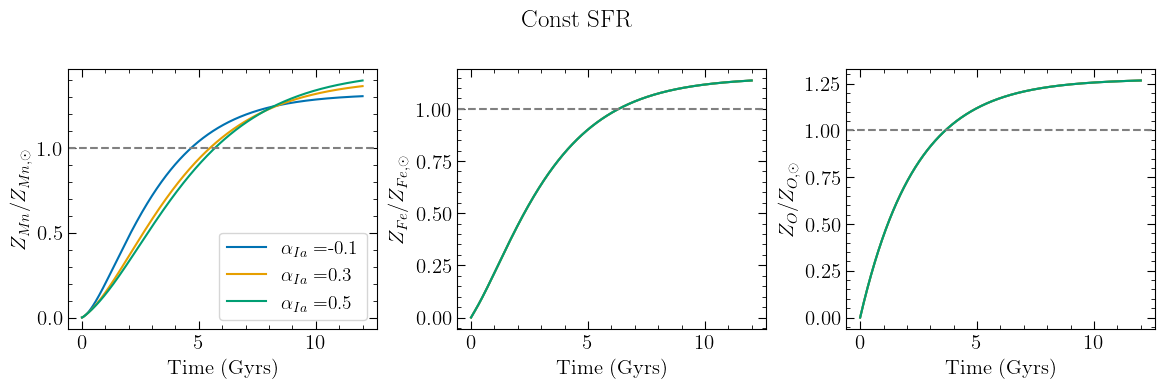

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_Mn()/gals_c[i].SolarMn, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')
plt.legend()

plt.subplot(1,3,2)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_Fe()/gals_c[i].SolarFe, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_O()/gals_c[i].SolarO, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')

plt.suptitle('Const SFR')
plt.tight_layout()

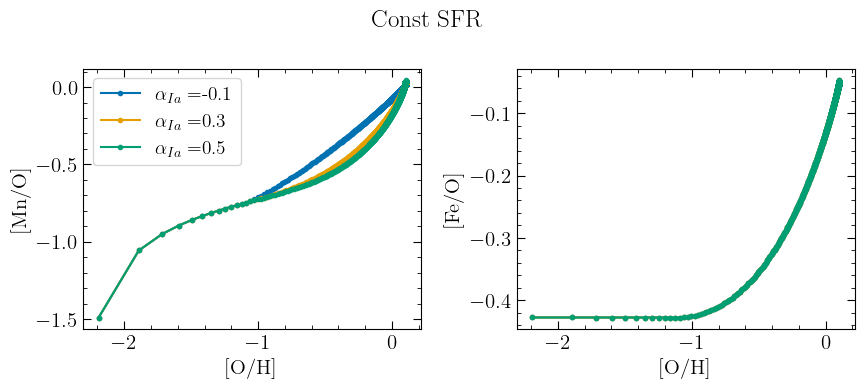

In [13]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(alpha_Ias)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:], label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,2,2)
for i in range(len(alpha_Ias)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Fe_O[1:], label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Const SFR')
plt.tight_layout()

(-0.7, 0.0)

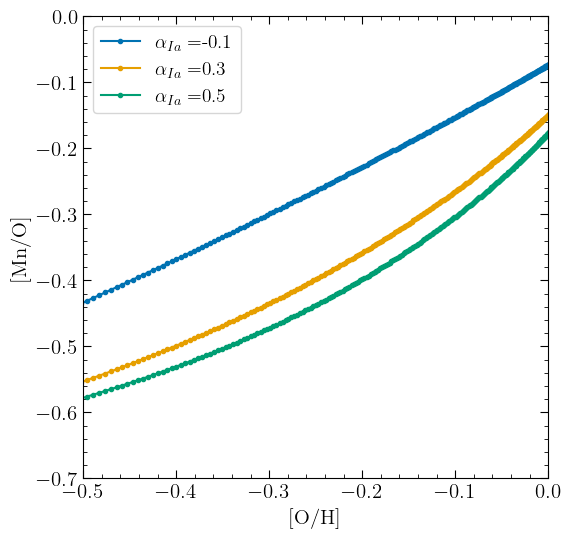

In [14]:
plt.figure(figsize=(6,6))

for i in range(len(alpha_Ias)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:], label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()
plt.xlim(-0.5, 0)
plt.ylim(-0.7, 0)

## 1.2) Exp SFR

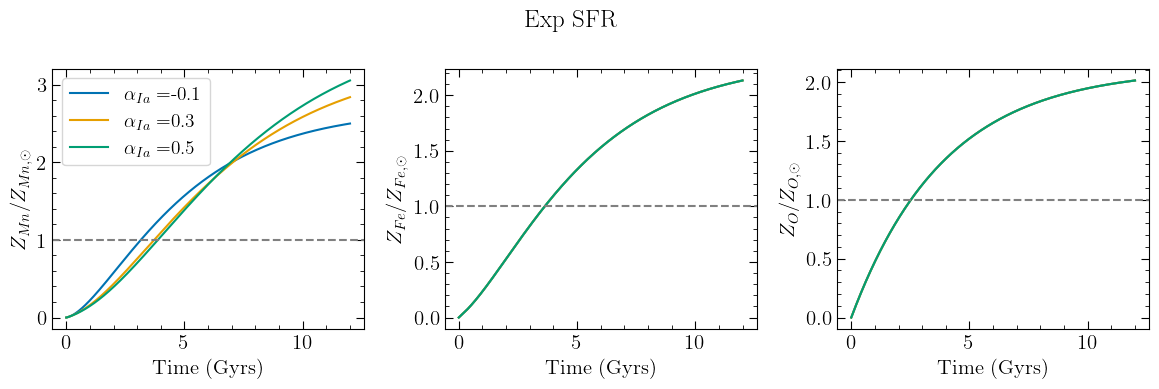

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_Mn()/gals_e[i].SolarMn, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')
plt.legend()

plt.subplot(1,3,2)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_Fe()/gals_e[i].SolarFe, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(alpha_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_O()/gals_e[i].SolarO, label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')

plt.suptitle('Exp SFR')
plt.tight_layout()

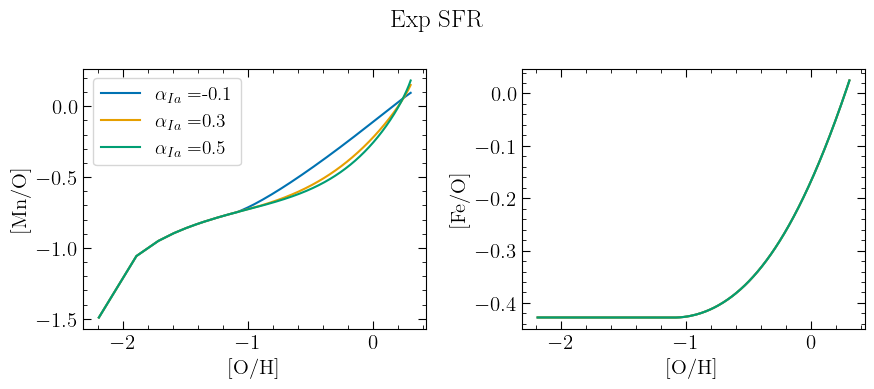

In [20]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(alpha_Ias)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Mn_O[1:], label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,2,2)
for i in range(len(alpha_Ias)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Fe_O[1:], label = r"$\alpha_{Ia} = $" + f"{alpha_Ias[i]}", color = colors[i])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Exp SFR')
plt.tight_layout()

# Turning off CC and Ia dependances

In [22]:
gal_only_Ia = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_Ia_Mn=0.30, alpha_cc_Mn=0, eta=1.5, tau_star = 5)
gal_only_CC = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_Ia_Mn=0, alpha_cc_Mn=0.17, eta=1.5, tau_star = 5)

Text(0, 0.5, '[Mn/O]')

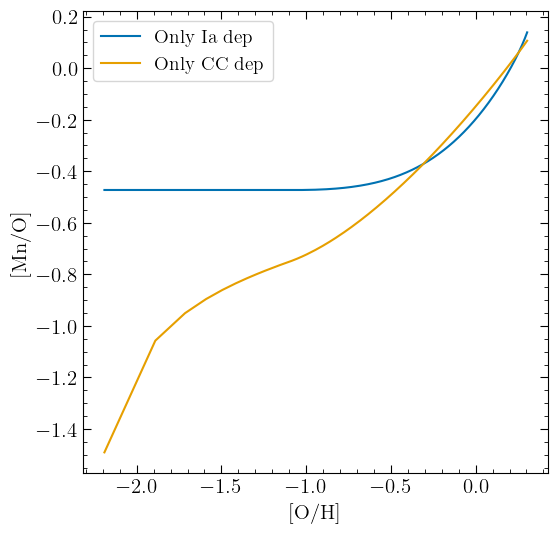

In [28]:
plt.figure(figsize=(6,6))

plt.plot(gal_only_Ia.O_H[1:], gal_only_Ia.Mn_O[1:], label = "Only Ia dep", color = colors[0])
plt.plot(gal_only_CC.O_H[1:], gal_only_CC.Mn_O[1:], label = "Only CC dep", color = colors[1])

plt.legend()
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')

In [29]:
len(t_array)

1000

In [30]:
t_array

array([1.00000000e-04, 1.21119119e-02, 2.41238238e-02, 3.61357357e-02,
       4.81476476e-02, 6.01595596e-02, 7.21714715e-02, 8.41833834e-02,
       9.61952953e-02, 1.08207207e-01, 1.20219119e-01, 1.32231031e-01,
       1.44242943e-01, 1.56254855e-01, 1.68266767e-01, 1.80278679e-01,
       1.92290591e-01, 2.04302503e-01, 2.16314414e-01, 2.28326326e-01,
       2.40338238e-01, 2.52350150e-01, 2.64362062e-01, 2.76373974e-01,
       2.88385886e-01, 3.00397798e-01, 3.12409710e-01, 3.24421622e-01,
       3.36433534e-01, 3.48445445e-01, 3.60457357e-01, 3.72469269e-01,
       3.84481181e-01, 3.96493093e-01, 4.08505005e-01, 4.20516917e-01,
       4.32528829e-01, 4.44540741e-01, 4.56552653e-01, 4.68564565e-01,
       4.80576476e-01, 4.92588388e-01, 5.04600300e-01, 5.16612212e-01,
       5.28624124e-01, 5.40636036e-01, 5.52647948e-01, 5.64659860e-01,
       5.76671772e-01, 5.88683684e-01, 6.00695596e-01, 6.12707508e-01,
       6.24719419e-01, 6.36731331e-01, 6.48743243e-01, 6.60755155e-01,
      